In [1]:
import os
import cv2
import torch
from PIL import Image
from tqdm import tqdm
import sys
import types
import torchvision.transforms.functional as F

# Fix for some library versions
sys.modules['torchvision.transforms.functional_tensor'] = F

# Model imports
from realesrgan import RealESRGANer
from gfpgan import GFPGANer
from facenet_pytorch import MTCNN
import cv2
import numpy as np


/home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Input (contains image folders) and output directories
INPUT_DIR = '../testing_preprocess/'
OUTPUT_DIR = '../testing_output'

# The upscale factor for GFPGAN (usually 2).
UPSCALE_FACTOR = 2

# The margin to add around the detected face, as a percentage of face width.
# For example, 0.5 means a 50% margin.
DYNAMIC_MARGIN_PERCENT = 0.5

# Number of images to process in a single batch for face detection.
# Adjust based on your GPU VRAM. (16, 32, or 64 are common values).
BATCH_SIZE = 32

In [2]:
def setup_models(scale=2):
    """Initializes and prepares all required models."""
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")

    print("Setting up face detector (MTCNN)...")
    face_detector = MTCNN(keep_all=True, device=device, select_largest=False)

    print("Setting up face restorer (GFPGAN)...")
    gfpgan_model_path = 'https://github.com/TencentARC/GFPGAN/releases/download/v1.3.4/GFPGANv1.4.pth'
    face_upsampler = GFPGANer(
        model_path=gfpgan_model_path,
        upscale=scale,
        arch='clean',
        channel_multiplier=2,
        bg_upsampler=None
    )

    print("All models are ready.")
    return face_detector, face_upsampler

In [4]:
def align_face(image, landmarks):
    """Rotates a cropped face image to make the eyes horizontal."""
    left_eye = landmarks[0]
    right_eye = landmarks[1]
    delta_x = right_eye[0] - left_eye[0]
    delta_y = right_eye[1] - left_eye[1]
    angle = np.degrees(np.arctan2(delta_y, delta_x))

    eye_center = (
        int((left_eye[0] + right_eye[0]) // 2),
        int((left_eye[1] + right_eye[1]) // 2)
    )

    h, w = image.shape[:2]
    rotation_matrix = cv2.getRotationMatrix2D(eye_center, angle, scale=1)
    aligned_image = cv2.warpAffine(image, rotation_matrix, (w, h))
    return aligned_image

Memulai tes visual lengkap untuk: frame_second_1_frame_0.png
Inisialisasi model terlebih dahulu...
Using device: cuda
Setting up face detector (MTCNN)...
Setting up face restorer (GFPGAN)...


/home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/.venv/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/.venv/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


All models are ready.
Ditemukan 1 wajah. Memproses wajah pertama...
Wajah berhasil di-crop & align. Ukuran: (202, 176, 3)
Memasukkan ke GFPGAN untuk restorasi...
GAGAL: GFPGAN tidak mengembalikan hasil gambar.


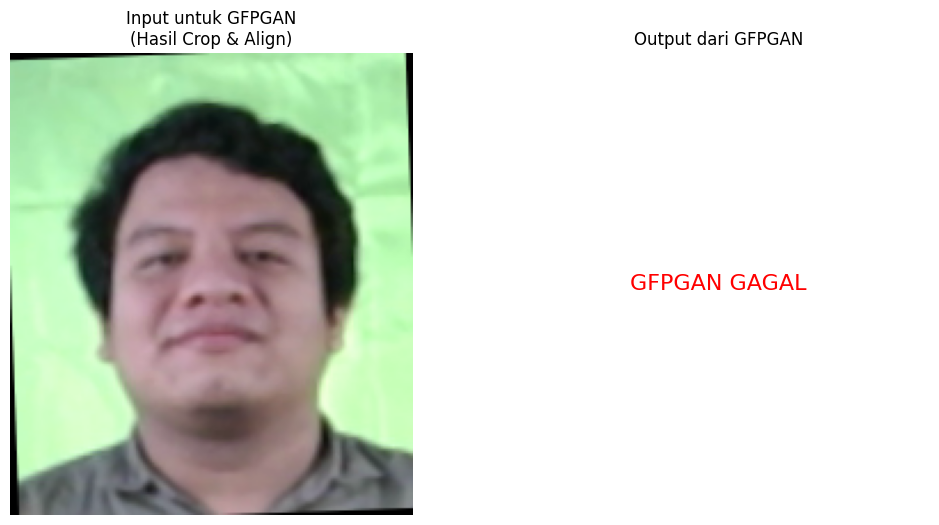

: 

In [ ]:
import matplotlib.pyplot as plt

# --- 1. UBAH PATH GAMBAR DI SINI ---
# Ganti dengan path lengkap ke salah satu gambar dari dataset Anda.
path_gambar_tes = '../testing_preprocess/Rendah/106/frame_second_1_frame_0.png'
# -----------------------------------

print(f"Memulai tes visual lengkap untuk: {os.path.basename(path_gambar_tes)}")

# Inisialisasi model jika belum ada
if 'face_detector' not in locals() or 'face_upsampler' not in locals():
    print("Inisialisasi model terlebih dahulu...")
    face_detector, face_upsampler = setup_models()

# Muat gambar
img_bgr = cv2.imread(path_gambar_tes)
input_gfpgan = None
output_gfpgan = None

if img_bgr is not None:
    try:
        # Deteksi, Crop, dan Align
        pil_image = Image.fromarray(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
        boxes, _, landmarks = face_detector.detect(pil_image, landmarks=True)

        if boxes is not None and len(boxes) > 0:
            print(f"Ditemukan {len(boxes)} wajah. Memproses wajah pertama...")
            box, landmark = boxes[0], landmarks[0]

            x1, y1, x2, y2 = [int(c) for c in box]
            h, w, _ = img_bgr.shape
            margin = int((x2 - x1) * DYNAMIC_MARGIN_PERCENT)

            x1_m, y1_m = max(0, x1 - margin), max(0, y1 - margin)
            x2_m, y2_m = min(w, x2 + margin), min(h, y2 + margin)

            cropped_face = img_bgr[y1_m:y2_m, x1_m:x2_m]

            if cropped_face.size > 0:
                adjusted_landmarks = landmark - np.array([x1_m, y1_m])
                aligned_face = align_face(cropped_face, adjusted_landmarks)
                input_gfpgan = aligned_face # Simpan input untuk ditampilkan
                print(f"Wajah berhasil di-crop & align. Ukuran: {aligned_face.shape}")

                # --- LANGKAH BARU: MASUKKAN KE GFPGAN ---
                print("Memasukkan ke GFPGAN untuk restorasi...")
                _, _, restored_output = face_upsampler.enhance(
                    aligned_face, has_aligned=True, only_center_face=True, paste_back=False
                )

                # Cek format output GFPGAN
                final_face = None
                if isinstance(restored_output, list) and restored_output:
                    final_face = restored_output[0]
                elif isinstance(restored_output, np.ndarray):
                    final_face = restored_output

                if final_face is not None:
                    print(f"GFPGAN berhasil! Ukuran output: {final_face.shape}")
                    output_gfpgan = final_face # Simpan output untuk ditampilkan
                else:
                    print("GAGAL: GFPGAN tidak mengembalikan hasil gambar.")
                # -----------------------------------------
        else:
            print("Gagal: Tidak ada wajah yang terdeteksi.")
    except Exception as e:
        print(f"Terjadi error: {e}")
else:
    print(f"Gagal memuat gambar dari path: {path_gambar_tes}")

# Tampilkan hasilnya secara berdampingan
if input_gfpgan is not None:
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    # Konversi BGR ke RGB untuk ditampilkan
    img_input_rgb = cv2.cvtColor(input_gfpgan, cv2.COLOR_BGR2RGB)

    # Tampilkan Input
    axes[0].imshow(img_input_rgb)
    axes[0].set_title("Input untuk GFPGAN\n(Hasil Crop & Align)")
    axes[0].axis('off')

    # Tampilkan Output
    if output_gfpgan is not None:
        img_output_rgb = cv2.cvtColor(output_gfpgan, cv2.COLOR_BGR2RGB)
        axes[1].imshow(img_output_rgb)
        axes[1].set_title("Output dari GFPGAN\n(Hasil Akhir)")
    else:
        # Jika GFPGAN gagal, tampilkan teks
        axes[1].text(0.5, 0.5, 'GFPGAN GAGAL', horizontalalignment='center', verticalalignment='center', fontsize=16, color='red')
        axes[1].set_title("Output dari GFPGAN")

    axes[1].axis('off')
    plt.show()
else:
    print("\nTidak ada hasil untuk ditampilkan.")